# ¡Hola Alejandro! <a class="tocSkip"></a>

Mi nombre es Oscar Flores y tengo el gusto de revisar tu proyecto. Si tienes algún comentario que quieras agregar en tus respuestas te puedes referir a mi como Oscar, no hay problema que me trates de tú.

Si veo un error en la primera revisión solamente lo señalaré y dejaré que tú encuentres de qué se trata y cómo arreglarlo. Debo prepararte para que te desempeñes como especialista en Data, en un trabajo real, el responsable a cargo tuyo hará lo mismo. Si aún tienes dificultades para resolver esta tarea, te daré indicaciones más precisas en una siguiente iteración.

Te dejaré mis comentarios más abajo - **por favor, no los muevas, modifiques o borres**

Comenzaré mis comentarios con un resumen de los puntos que están bien, aquellos que debes corregir y aquellos que puedes mejorar. Luego deberás revisar todo el notebook para leer mis comentarios, los cuales estarán en rectángulos de color verde, amarillo o rojo como siguen:

<div class='alert alert-block alert-success'>
<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Muy bien! Toda la respuesta fue lograda satisfactoriamente.
</div>

<div class='alert alert-block alert-warning'>
<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Existen detalles a mejorar. Existen recomendaciones.
</div>

<div class='alert alert-block alert-danger'>

<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Se necesitan correcciones en el bloque. El trabajo no puede ser aceptado con comentarios en rojo sin solucionar.
</div>

Cualquier comentario que quieras agregar entre iteraciones de revisión lo puedes hacer de la siguiente manera:

<div class='alert alert-block alert-info'>
<b>Respuesta estudiante.</b> <a class='tocSkip'></a>
</div>

Mucho éxito en el proyecto!

## Resumen de la revisión v1 <a class="tocSkip"></a>

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Buen trabajo Alejandro! Has completado correctamente todo lo necesario del notebook, realizaste un gran trabajo aplicando los conocimientos de analítica necesarios, se nota que los manejas muy bien. No tengo comentarios de corrección, tu proyecto está aprobado. Felicitaciones por completar el notebook en la primera revisión, mucho éxito en el siguiente sprint!

Saludos!

</div>

----

# Análisis de datos de Zuber

En este proyecto se analizan datos de viajes en taxi en Chicago con el objetivo de identificar patrones en el comportamiento de los pasajeros y evaluar el impacto de factores externos, como el clima, en la duración de los viajes.

Se trabajó con tres conjuntos de datos:

- Empresas de taxis y número de viajes
- Barrios y promedio de viajes finalizados
- Viajes desde el Loop hasta O'Hare con condiciones climáticas

El análisis incluye exploración de datos, visualización y una prueba de hipótesis.

### Preparacion de los datos

#### Importar librerias necesarias

In [24]:
import pandas as pd
import math
import scipy.stats as stats
import matplotlib.pyplot as plt

## Carga de datos

Se importan los archivos CSV proporcionados para el análisis.

In [25]:
company_trips = pd.read_csv('/datasets/project_sql_result_01.csv')
dropoff_trips = pd.read_csv('/datasets/project_sql_result_04.csv')
loop_ohare = pd.read_csv('/datasets/project_sql_result_07.csv')


## Exploración de datos:

### Empresas de taxis

Se analiza el dataset que contiene el número de viajes realizados por cada empresa de taxis durante el 15 y 16 de noviembre de 2017.

Se revisa:
- Estructura de los datos
- Tipos de variables
- Valores faltantes
- Duplicados

In [26]:
# Primer dataset
print(company_trips.head())
print(company_trips.info())
print(company_trips.describe())
print(company_trips.isna().sum())
print(company_trips.duplicated().sum())

                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                Medallion Leasing         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None
       trips_amount
count     64.000000
mean    2145.484375
std     3812.310186
min        2.000000
25%       20.750000
50%      178.500000
75%     2106.500000
max    19558.000000
company_name    0
trips_amount    0
dtype: int64
0


### Barrios

Este dataset contiene el promedio de viajes finalizados en cada barrio durante noviembre de 2017.

Se busca identificar:
- Distribución de los viajes
- Barrios con mayor demanda

In [27]:
# Segundo dataset
print(dropoff_trips.head())
print(dropoff_trips.info())
print(dropoff_trips.describe())
print(dropoff_trips.isna().sum())
print(dropoff_trips.duplicated().sum())

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None
       average_trips
count      94.000000
mean      599.953728
std      1714.591098
min         1.800000
25%        14.266667
50%        52.016667
75%       298.858333
max     10727.466667
dropoff_location_name    0
average_trips            0
dtype: int64
0


### Viajes del Loop a O'Hare

Este dataset contiene información sobre los viajes que comenzaron en el Loop y terminaron en el Aeropuerto Internacional O'Hare, junto con las condiciones climáticas al inicio del viaje y su duración en segundos.

En esta parte se revisa:
- la estructura del dataset,
- los tipos de datos,
- la presencia de valores ausentes,
- y posibles duplicados.

Además, se convierte la columna de fecha y hora a formato datetime para facilitar el análisis posterior y la prueba de hipótesis.

In [28]:
# Tercer dataset
print(loop_ohare.head())
print(loop_ohare.info())
print(loop_ohare.describe())
print(loop_ohare.isna().sum())
print(loop_ohare.duplicated().sum())

              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00               Good            2410.0
1  2017-11-25 14:00:00               Good            1920.0
2  2017-11-25 12:00:00               Good            1543.0
3  2017-11-04 10:00:00               Good            2512.0
4  2017-11-11 07:00:00               Good            1440.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB
None
       duration_seconds
count       1068.000000
mean        2071.731273
std          769.461125
min            0.000000
25%         1438.250000
50%         1980.000000
75%         2580.000000
max         7440.000000
start_ts       

## Limpieza y verificación de datos

Se verifican los tipos de datos y se realizan conversiones cuando es necesario.

En particular, la columna de fechas se convierte a formato datetime para facilitar su análisis.

In [29]:
loop_ohare['start_ts'] = pd.to_datetime(loop_ohare['start_ts'])

In [30]:
print(company_trips.dtypes)
print(dropoff_trips.dtypes)
print(loop_ohare.dtypes)

company_name    object
trips_amount     int64
dtype: object
dropoff_location_name     object
average_trips            float64
dtype: object
start_ts              datetime64[ns]
weather_conditions            object
duration_seconds             float64
dtype: object


<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>


Muy bien hecho con la revisión inicial de la data, ahora tenemos los tipos correctos y sabemos con claridad lo que contiene 



</div>

## Top 10 barrios por número de finalizaciones

Se identifican los 10 barrios con mayor promedio de viajes finalizados.

Esto permite detectar las zonas con mayor demanda de transporte en la ciudad.

In [31]:
top_10_neighborhoods = dropoff_trips.sort_values(
    by='average_trips', ascending=False
).head(10)

print(top_10_neighborhoods)


  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


Se logra observar que los tres neighborhoods que mayor demanda de transporte en la ciudad son Loop, River North y Streeterville, los cuales contienen la mayor parte de la demanda moviliaria de dicha ciudad, lo que puede indicar que estas zonas son laborales.

## Análisis de barrios

Se visualizan los 10 barrios con mayor número de finalizaciones de viajes.

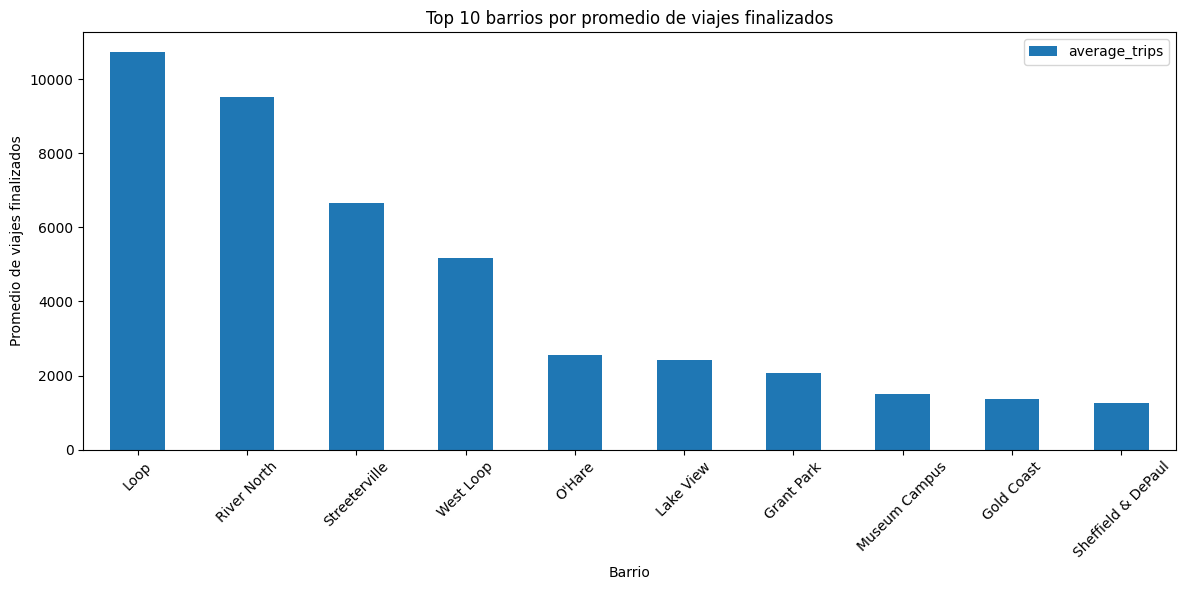

In [32]:
top_10_neighborhoods.plot(
    x='dropoff_location_name',
    y='average_trips',
    kind='bar',
    figsize=(12, 6)
)
plt.title('Top 10 barrios por promedio de viajes finalizados')
plt.xlabel('Barrio')
plt.ylabel('Promedio de viajes finalizados')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

¡Buen trabajo obteniendo el top de barrios! El gráfico está ordenado de mayor a menor, lo que permite notar correctamente que Loop Y River North son los principales destinos. Tal vez tienen atractivos importantes que los hacen lugares de muchas visitas.

</div>

## Análisis de empresas de taxis

Se construye un gráfico para visualizar el número de viajes por empresa.

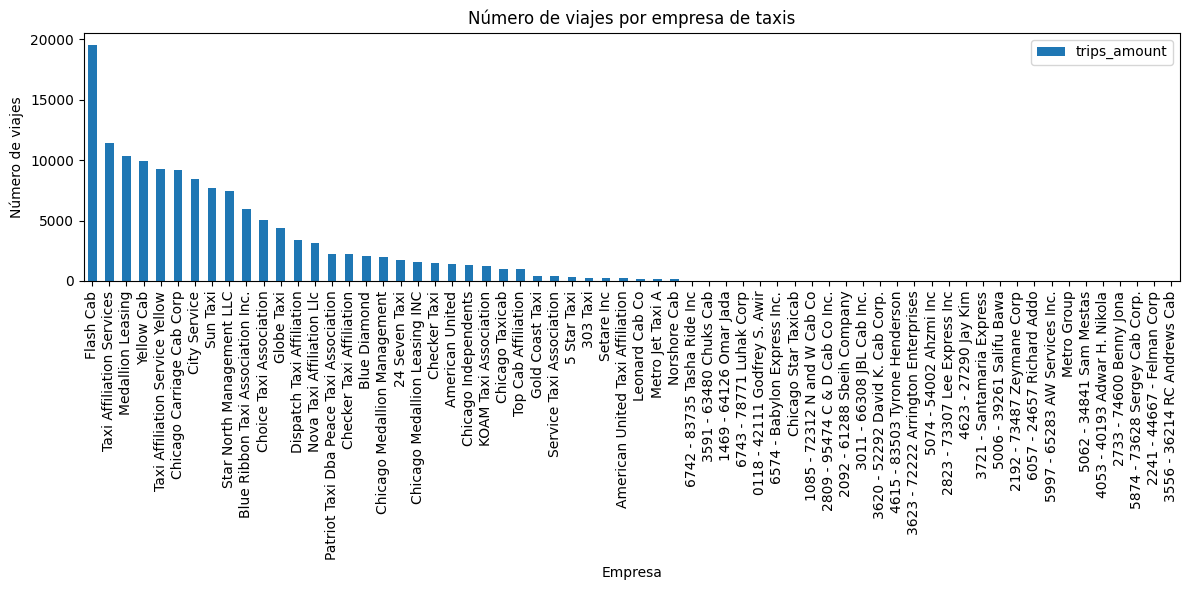

In [33]:
company_trips.sort_values(by='trips_amount', ascending=False).plot(
    x='company_name',
    y='trips_amount',
    kind='bar',
    figsize=(12, 6)
)
plt.title('Número de viajes por empresa de taxis')
plt.xlabel('Empresa')
plt.ylabel('Número de viajes')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Respecto al numero de viajes por empresa de taxis se logra apreciar que hay una alta demanda en la empresa Flash Cab, la cual es la empresa líder, luego le siguen empresas que compiten por un posicionamiento ligero en el mercado y el resto de las empresas muy probablemente son de zonas no muy concurridas de la ciudad, lo que hace que sean de nichos específicos.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

¡Muy buen trabajo con la gráfica! Observamos que Flash Cab tiene el liderazgo de cantidad de viajes, bastante más arriba que el competidor que le sigue. Esta concentración de mercado se puede dar por varios factores como cobertura, cantidad de vehículos o buenas estrategias comerciales.

</div>

## Prueba de hipótesis

Se analiza si la duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia durante los sábados lluviosos.

Se comparan dos grupos:
- Viajes con clima desfavorable (Bad)
- Viajes con clima favorable (Good)

#### Formulación de hipótesis

Hipótesis nula:

$$
 H_0: \mu_{Bad} = \mu_{Good}
$$

Hipótesis alternativa:

$$
H_1: \mu_{Bad} \neq \mu_{Good}
$$

#### Método de prueba

Se utiliza una prueba t de Student para muestras independientes, ya que se comparan las medias de dos grupos diferentes.

Se emplea la versión con varianzas desiguales (Welch), dado que no se puede asumir igualdad de varianzas.

Nivel de significación:

$$
\alpha = 0.05
$$

In [34]:
rainy_saturdays = loop_ohare[loop_ohare['weather_conditions'] == 'Bad']['duration_seconds']
good_saturdays = loop_ohare[loop_ohare['weather_conditions'] == 'Good']['duration_seconds']

alpha = 0.05

results = stats.ttest_ind(rainy_saturdays, good_saturdays, equal_var=False)

print('Promedio en sábados lluviosos:', rainy_saturdays.mean())
print('Promedio en sábados no lluviosos:', good_saturdays.mean())
print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print("Se rechaza la hipótesis nula")
else:
    print("No se rechaza la hipótesis nula")

Promedio en sábados lluviosos: 2427.2055555555557
Promedio en sábados no lluviosos: 1999.6756756756756
p-value: 6.738994326108734e-12
Se rechaza la hipótesis nula


Se rechaza la hipótesis nula y por tanto se puede afirmar que la media de los viajes varia dependiendo del clima con una certeza del 95%.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Bien hecho con el test de hipótesis, fue realizado de forma correcta. 

Es importante mencionar que el t-test asume que las dos muestras tienen varianzas iguales. Para verificar esa igualdad de varianzas podemos usar el **test de Levene**. Este nos dice si la variabilidad entre los grupos es estadísticamente diferente. En corto, el flujo sería así

1. Usamos `levene()` para verificar si las varianzas son iguales.
2. Dependiendo del resultado, usamos `ttest_ind()` con el argumento `equal_var`:
   - `equal_var=True` si Levene dice que las varianzas son iguales (p > 0.05).
   - `equal_var=False` si Levene dice que las varianzas son diferentes (p < 0.05).





</div>

## Conclusiones

El análisis exploratorio y la prueba de hipótesis permitieron identificar patrones relevantes en la dinámica del mercado de taxis en Chicago, así como cuantificar el impacto de variables externas, específicamente las condiciones climáticas, sobre la duración de los viajes.



### 1. Estructura del mercado

El análisis de la distribución de viajes por empresa revela una alta concentración del mercado en un reducido número de compañías, destacando Flash Cab como el principal actor en términos de volumen.

Desde una perspectiva analítica, esto sugiere una distribución sesgada (tipo long tail), donde:
- pocas empresas concentran la mayoría de la demanda,
- mientras que un gran número de compañías tienen participaciones marginales.

**Implicación:**
El mercado presenta características cercanas a un oligopolio en términos de volumen de viajes.

**Relevancia para Zuber:**
La entrada al mercado no debe basarse en competir directamente en volumen, sino en:
- diferenciación del servicio,
- eficiencia operativa,
- y targeting de segmentos específicos.



### 2. Distribución espacial de la demanda

El análisis de los barrios evidencia que la demanda de viajes está altamente concentrada en zonas específicas, principalmente:
- Loop,
- River North,
- Streeterville.

Este patrón sugiere una fuerte correlación entre densidad de actividad urbana (económica, laboral y turística) y volumen de viajes.

**Interpretación:**
La movilidad urbana presenta hubs claramente definidos, lo cual es consistente con modelos de demanda centralizada en ciudades metropolitanas.

**Implicación operativa:**
La asignación de conductores debe optimizarse espacialmente, priorizando zonas de alta densidad de demanda para maximizar la eficiencia y reducir tiempos de espera.



### 3. Impacto del clima en la duración de los viajes

Se evaluó la hipótesis:

- **H₀:** μ₍Bad₎ = μ₍Good₎  
- **H₁:** μ₍Bad₎ ≠ μ₍Good₎  

Se utilizó una prueba t de Student para muestras independientes (Welch), adecuada dado que:
- se comparan dos grupos independientes,
- no se asume igualdad de varianzas,
- la variable de interés (duración) es continua.

Con un nivel de significación α = 0.05, se obtuvo un p-value significativamente inferior a α.

**Resultado:**
Se rechaza la hipótesis nula.

**Conclusión estadística:**
Existe evidencia suficiente para afirmar que las condiciones climáticas adversas (lluvia/tormenta) afectan significativamente la duración de los viajes.



### 4. Interpretación del efecto observado

El incremento en la duración promedio de los viajes bajo condiciones climáticas desfavorables puede explicarse por múltiples factores:

- reducción de la velocidad promedio del tráfico,
- incremento en la congestión vehicular,
- aumento simultáneo de la demanda de transporte,
- posibles cambios en el comportamiento de los conductores.

Este resultado es consistente con modelos de tráfico urbano bajo condiciones adversas.



### 5. Valor estratégico del análisis

Los resultados obtenidos tienen implicaciones directas en la toma de decisiones basada en datos:

- **Optimización operativa:** permite ajustar la asignación de conductores según patrones espaciales y condiciones externas.
- **Modelado predictivo:** el clima emerge como una variable explicativa clave para predecir duración de viajes.
- **Pricing dinámico:** la variación en duración y demanda bajo lluvia sugiere oportunidades para estrategias de precios adaptativos.



### 6. Recomendaciones basadas en datos

A partir del análisis, se proponen las siguientes acciones:

- Incorporar variables climáticas en modelos predictivos de duración y demanda.
- Implementar sistemas de pricing dinámico sensibles a condiciones meteorológicas.
- Priorizar la cobertura en zonas de alta densidad (hubs urbanos).
- Desarrollar estrategias de entrada enfocadas en nichos desatendidos por los líderes del mercado.
- Monitorear continuamente métricas de desempeño bajo distintos escenarios climáticos.



### 7. Conclusión final

El comportamiento de los viajes en Chicago está determinado tanto por factores estructurales (concentración del mercado y distribución espacial de la demanda) como por variables externas (clima).

La evidencia estadística demuestra que el clima tiene un efecto significativo sobre la duración de los viajes, lo que refuerza la importancia de integrar este tipo de variables en modelos analíticos y decisiones operativas.

En este contexto, Zuber puede aprovechar estos insights para diseñar una estrategia basada en datos que optimice su entrada al mercado, mejore la eficiencia del servicio y aumente su competitividad frente a actores establecidos.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>

Excelente, bien hecho con las conclusiones, logras señalar todos los puntos más relevantes del análisis. 



</div>